In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.pipeline import Pipeline

from scipy.stats import zscore

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('/content/mapped_Dataset.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,NaN,Not Mapped,Physician Referral,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,Emergency,Discharged to home,Emergency Room,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,Emergency,Discharged to home,Emergency Room,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,Emergency,Discharged to home,Emergency Room,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,Emergency,Discharged to home,Emergency Room,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Records: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (101766, 50)
Records: 101,766
Features: 50

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [4]:
print(f"\nMissing values:\n{df.isnull().sum()}")


Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id            5291
discharge_disposition_id     3691
admission_source_id          6781
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                    

In [5]:
print(f"\nData types:\n{df.dtypes}")


Data types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepi

In [6]:
columns_to_drop = [
    'encounter_id',
    'patient_nbr',
    'payer_code',
    'discharge_disposition_id',
    'admission_source_id',
    'weight',
    'max_glu_serum',
    'A1Cresult'
]

df = df.drop(columns=columns_to_drop)

In [7]:
age_bins = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_bins)
df = df.drop(columns=['age'])

In [8]:
top_races = df['race'].value_counts().head(5).index
df['race'] = df['race'].apply(lambda x: x if x in top_races else 'Other')

In [9]:
# 1. Insulin user
df['insulin_user'] = (df['insulin'] != 'No').astype(int)

# 2. Metformin user (including combos)
metformin_cols = ['metformin', 'glyburide-metformin', 'glipizide-metformin',
                  'metformin-rosiglitazone', 'metformin-pioglitazone']
df['metformin_user'] = (df[metformin_cols] != 'No').any(axis=1).astype(int)

# 3. Sulfonamide user
sulfa_cols = ['glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
              'chlorpropamide', 'tolazamide']
df['sulfonamide_user'] = (df[sulfa_cols] != 'No').any(axis=1).astype(int)

# 4. Thiazolidinedione (TZD) user
tzd_cols = ['pioglitazone', 'rosiglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']
df['thiazolidinedione_user'] = (df[tzd_cols] != 'No').any(axis=1).astype(int)

# 5. Medication intensity (0-10 scale)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin']
med_count = (df[med_cols] != 'No').sum(axis=1)
df['medication_intensity'] = (med_count / len(med_cols)) * 10

# 6. Medication changed
df['medication_changed'] = (df['change'] != 'No').astype(int)

# DROP all original medication columns
med_to_drop = med_cols + ['glyburide-metformin', 'glipizide-metformin',
                          'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                          'metformin-pioglitazone', 'change', 'diabetesMed']
df = df.drop(columns=med_to_drop)

In [10]:
# Binary flags for major conditions
df['has_diabetes'] = (
    df['diag_1'].astype(str).str[:3].isin(['250']) |
    df['diag_2'].astype(str).str[:3].isin(['250']) |
    df['diag_3'].astype(str).str[:3].isin(['250'])
).astype(int)

df['has_hypertension'] = (
    df['diag_1'].astype(str).str[:3].isin(['401', '402', '403']) |
    df['diag_2'].astype(str).str[:3].isin(['401', '402', '403']) |
    df['diag_3'].astype(str).str[:3].isin(['401', '402', '403'])
).astype(int)

df['has_renal_disease'] = (
    df['diag_1'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585']) |
    df['diag_2'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585']) |
    df['diag_3'].astype(str).str[:3].isin(['580', '581', '582', '583', '584', '585'])
).astype(int)

df['has_heart_disease'] = (
    df['diag_1'].astype(str).str[:3].isin(['410', '411', '412', '413', '414']) |
    df['diag_2'].astype(str).str[:3].isin(['410', '411', '412', '413', '414']) |
    df['diag_3'].astype(str).str[:3].isin(['410', '411', '412', '413', '414'])
).astype(int)

# Comorbidity count
df['comorbidity_count'] = (
    df['has_hypertension'] + df['has_renal_disease'] + df['has_heart_disease']
)

# DROP raw diagnosis codes
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

In [11]:
admission_mapping = {
    '1': 'Emergency', '2': 'Urgent', '3': 'Elective',
    '5': 'Newborn', '7': 'Trauma'
}
df['admission_type'] = df['admission_type_id'].astype(str).map(admission_mapping)
df['admission_type'] = df['admission_type'].astype('category')
df['is_emergency'] = (df['admission_type'] == 'Emergency').astype(int)
df = df.drop(columns=['admission_type_id'])

In [12]:
missing_pct = df['medical_specialty'].isna().sum() / len(df) * 100

if missing_pct > 30:
    df = df.drop(columns=['medical_specialty'])
else:
    top_specs = df['medical_specialty'].value_counts().head(10).index
    df['medical_specialty'] = df['medical_specialty'].apply(
        lambda x: x if x in top_specs else 'Other'
    )
    df['medical_specialty'] = df['medical_specialty'].astype('category')

In [13]:
def create_complexity_index(df):
    num_med = df['num_medications'].fillna(0)
    num_proc = df['num_procedures'].fillna(0)
    los = df['time_in_hospital'].fillna(0)
    num_diag = df['number_diagnoses'].fillna(0)
    med_intensity = df['medication_intensity'].fillna(0)

    num_med_norm = num_med / (num_med.max() + 1)
    num_proc_norm = num_proc / (num_proc.max() + 1)
    los_norm = los / (los.max() + 1)
    num_diag_norm = num_diag / (num_diag.max() + 1)
    med_intensity_norm = med_intensity / 10

    df['patient_complexity'] = (
        0.25 * num_med_norm +
        0.15 * num_proc_norm +
        0.20 * los_norm +
        0.20 * num_diag_norm +
        0.20 * med_intensity_norm
    ) * 100

    return df

df = create_complexity_index(df)

In [14]:
def classify_engagement(row):
    outpt = row['number_outpatient']
    emerg = row['number_emergency']
    inpt = row['number_inpatient']

    if outpt > 5 and emerg < 1 and inpt < 1:
        return 'Preventive_Engaged'
    elif emerg > 2 or inpt > 2:
        return 'Acute_High_Risk'
    elif outpt > 2 and emerg + inpt > 1:
        return 'Mixed_Moderate'
    else:
        return 'Low_Engagement'

df['engagement_pattern'] = df.apply(classify_engagement, axis=1)
df['engagement_pattern'] = df['engagement_pattern'].astype('category')
df['total_recent_visits'] = (df['number_outpatient'] +
                              df['number_emergency'] +
                              df['number_inpatient'])

In [15]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical with 'Unknown'
categorical_cols = df.select_dtypes(include='category').columns
for col in categorical_cols:
    if 'Unknown' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories('Unknown')
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# Verify no nulls
print(df.isna().sum())

race                      0
gender                    0
time_in_hospital          0
medical_specialty         0
num_lab_procedures        0
num_procedures            0
num_medications           0
number_outpatient         0
number_emergency          0
number_inpatient          0
number_diagnoses          0
readmitted                0
age_numeric               0
insulin_user              0
metformin_user            0
sulfonamide_user          0
thiazolidinedione_user    0
medication_intensity      0
medication_changed        0
has_diabetes              0
has_hypertension          0
has_renal_disease         0
has_heart_disease         0
comorbidity_count         0
admission_type            0
is_emergency              0
patient_complexity        0
engagement_pattern        0
total_recent_visits       0
dtype: int64


In [20]:
# @title
def select_k_best(df_input, y, k=15):
    df_encoded = df_input.copy()

    # Identify all non-numeric columns (object or category dtypes)
    non_numeric_cols = df_encoded.select_dtypes(include=['object', 'category']).columns

    for col in non_numeric_cols:
        # Convert to string first to handle potential mixed types or NaNs gracefully
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(df_encoded, y)

    scores = pd.DataFrame({
        'Feature': df_encoded.columns,
        'Score': selector.scores_
    }).sort_values('Score', ascending=False)

    # Return selected features from the original (unencoded) dataframe
    return df_input[scores.head(k)['Feature'].tolist()], scores

# Define y as the encoded 'readmitted' column
y = LabelEncoder().fit_transform(df['readmitted'])

X_selected, scores = select_k_best(df.drop(columns=['readmitted']), y, k=15)
print(scores.head(15))

                Feature        Score
9      number_inpatient  2963.323843
27  total_recent_visits  2419.060564
26   engagement_pattern  1084.199942
10     number_diagnoses   655.464952
8      number_emergency   573.257193
7     number_outpatient   355.232693
2      time_in_hospital   170.330886
25   patient_complexity   160.766145
3     medical_specialty   147.855583
6       num_medications   136.749211
12         insulin_user   117.760507
17   medication_changed   108.138659
5        num_procedures   103.541267
20    has_renal_disease    97.875254
4    num_lab_procedures    80.210718


In [17]:
# Select numeric columns only
numeric_features = X_selected.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_scaled = X_selected.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_selected[numeric_features])

# Verify: mean ~0, std ~1
print(X_scaled[numeric_features].describe())

       number_inpatient  total_recent_visits  number_diagnoses  \
count      1.017660e+05         1.017660e+05      1.017660e+05   
mean      -2.115583e-17         4.133417e-17      1.988509e-16   
std        1.000005e+00         1.000005e+00      1.000005e+00   
min       -5.032762e-01        -5.248168e-01     -3.321596e+00   
25%       -5.032762e-01        -5.248168e-01     -7.357332e-01   
50%       -5.032762e-01        -5.248168e-01      2.986119e-01   
75%        2.885790e-01         3.478712e-01      8.157845e-01   
max        1.612568e+01         3.438270e+01      4.435992e+00   

       number_emergency  number_outpatient  time_in_hospital  \
count      1.017660e+05       1.017660e+05      1.017660e+05   
mean       3.044206e-17       2.010851e-17      5.082986e-17   
std        1.000005e+00       1.000005e+00      1.000005e+00   
min       -2.126202e-01      -2.914615e-01     -1.137649e+00   
25%       -2.126202e-01      -2.914615e-01     -8.026506e-01   
50%       -2.126202e-

In [18]:
print(f"Final shape: {X_selected.shape}")
print(f"\nData types:\n{X_selected.dtypes}")
print(f"\nMissing values:\n{X_selected.isna().sum()}")
print(f"\nFeature summary:\n{X_selected.describe()}")
print(f"\nCategorical values:\n{X_selected.select_dtypes('category').nunique()}")

Final shape: (101766, 15)

Data types:
number_inpatient          int64
total_recent_visits       int64
engagement_pattern     category
number_diagnoses          int64
number_emergency          int64
number_outpatient         int64
time_in_hospital          int64
patient_complexity      float64
medical_specialty      category
num_medications           int64
insulin_user              int64
medication_changed        int64
num_procedures            int64
has_renal_disease         int64
num_lab_procedures        int64
dtype: object

Missing values:
number_inpatient       0
total_recent_visits    0
engagement_pattern     0
number_diagnoses       0
number_emergency       0
number_outpatient      0
time_in_hospital       0
patient_complexity     0
medical_specialty      0
num_medications        0
insulin_user           0
medication_changed     0
num_procedures         0
has_renal_disease      0
num_lab_procedures     0
dtype: int64

Feature summary:
       number_inpatient  total_recent_visits

### Optimal Number of Clusters

To determine the optimal number of clusters for the dataset, we will employ two common methods:

1.  **Elbow Method**: This method looks at the total within-cluster sum of squares (WCSS) as a function of the number of clusters. The 'elbow' point in the plot, where the rate of decrease in WCSS sharply changes, is often considered a good indicator of the optimal number of clusters.
2.  **Silhouette Score**: The silhouette score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. A higher average silhouette score across all objects suggests better-defined clusters.

In [21]:
# One-hot encode categorical features in X_scaled

# Identify categorical columns in X_scaled
categorical_features = X_scaled.select_dtypes(include='category').columns

# Apply one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_categorical = encoder.fit_transform(X_scaled[categorical_features])

# Create a DataFrame from the encoded categorical features
X_encoded_categorical_df = pd.DataFrame(
    X_encoded_categorical,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_scaled.index
)

# Drop original categorical columns from X_scaled and concatenate with encoded ones
X_processed = pd.concat([X_scaled.drop(columns=categorical_features), X_encoded_categorical_df], axis=1)

print(f"Shape of X_processed: {X_processed.shape}")
print(f"First 5 rows of X_processed:\n{X_processed.head()}")

Shape of X_processed: (101766, 28)
First 5 rows of X_processed:
   number_inpatient  total_recent_visits  number_diagnoses  number_emergency  \
0         -0.503276            -0.524817         -3.321596          -0.21262   
1         -0.503276            -0.524817          0.815784          -0.21262   
2          0.288579             0.784215         -0.735733          -0.21262   
3         -0.503276            -0.524817         -0.218561          -0.21262   
4         -0.503276            -0.524817         -1.252906          -0.21262   

   number_outpatient  time_in_hospital  patient_complexity  num_medications  \
0          -0.291461         -1.137649           -2.433089        -1.848268   
1          -0.291461         -0.467653           -0.287836         0.243390   
2           1.286748         -0.802651            0.217422        -0.371804   
3          -0.291461         -0.802651           -0.539250        -0.002688   
4          -0.291461         -1.137649           -1.374939  

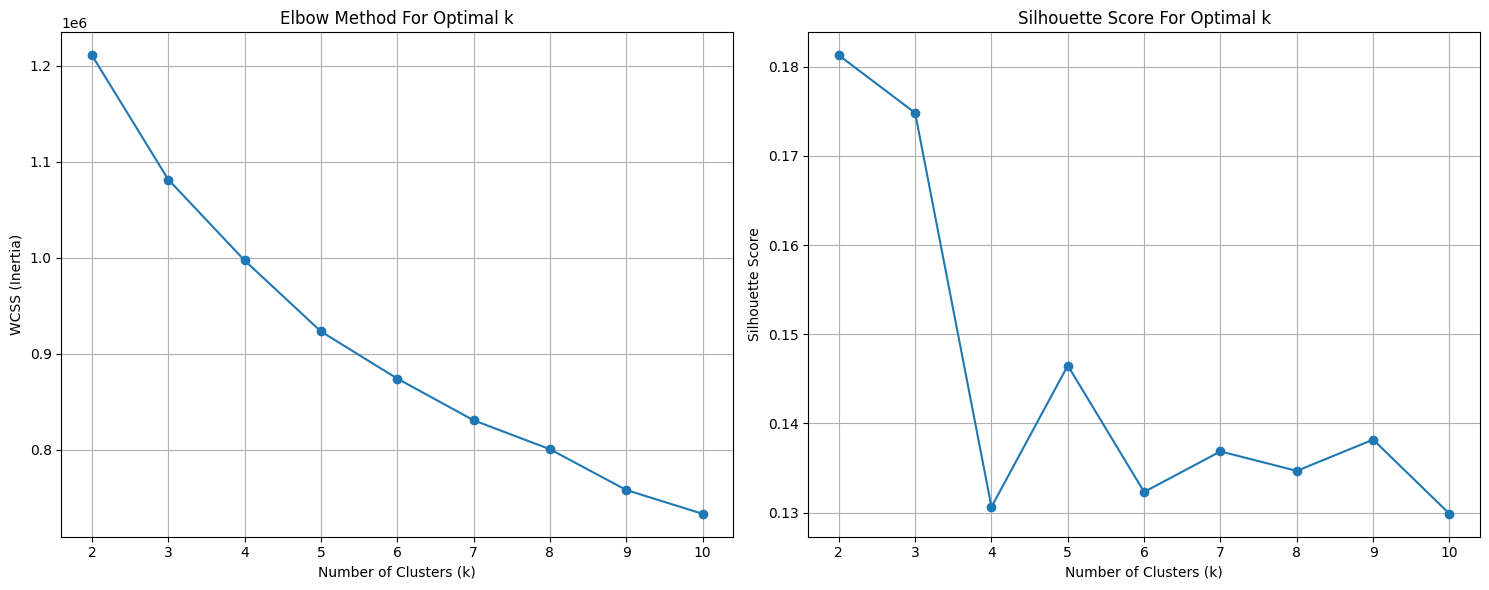

In [23]:
# Determine the optimal number of clusters using Elbow Method and Silhouette Score

wcss = [] # Within-Cluster Sum of Squares
silhouette_scores = []
k_range = range(2, 11) # Test k from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_, n_jobs=-1))

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Elbow Method Plot
axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(True)

# Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score For Optimal k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Based on the Elbow Method and Silhouette Score plots:

*   **Elbow Method**: The 'elbow' appears to be around **k=3 or k=4**, where the decrease in WCSS starts to slow down significantly.
*   **Silhouette Score**: The silhouette score is highest at **k=2**, but remains relatively high for k=3 and k=4, suggesting reasonable cluster separation.

Considering both plots, **k=3 or k=4** seems like a reasonable choice for the number of clusters. Let's proceed with `k=3` as a starting point, as it provides a good balance and is often a good compromise between model complexity and interpretability.

In [27]:
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X_processed)

df['cluster'] = kmeans_model.labels_
display(df.head())

,race,gender,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,has_hypertension,has_renal_disease,has_heart_disease,comorbidity_count,admission_type,is_emergency,patient_complexity,engagement_pattern,total_recent_visits,cluster
0,Caucasian,Female,1,Other,41,0,1,0,0,0,...,0,0,0,0,Unknown,0,2.814682,Low_Engagement,0,1
1,Caucasian,Female,3,?,59,0,18,0,0,0,...,0,0,0,0,Unknown,0,21.187151,Low_Engagement,0,1
2,AfricanAmerican,Female,2,?,11,5,13,2,0,1,...,0,0,0,0,Unknown,0,25.514302,Low_Engagement,3,1
3,Caucasian,Male,2,?,44,1,16,0,0,0,...,1,0,0,1,Unknown,0,19.033978,Low_Engagement,0,1
4,Caucasian,Male,1,?,51,0,8,0,0,0,...,0,0,0,0,Unknown,0,11.876933,Low_Engagement,0,1


### Interpreting the Clusters

To interpret the characteristics of each cluster, we will examine the average values of the features within each cluster.

In [29]:
numeric_cols_selected = X_selected.select_dtypes(include=[np.number]).columns
cluster_summary_numeric = df.groupby('cluster')[numeric_cols_selected].mean()
display(cluster_summary_numeric)


,number_inpatient,total_recent_visits,number_diagnoses,number_emergency,number_outpatient,time_in_hospital,patient_complexity,num_medications,insulin_user,medication_changed,num_procedures,has_renal_disease,num_lab_procedures
cluster,,,,,,,,,,,,,
0,0.453707,0.769736,8.320481,0.107111,0.208918,7.012094,33.006243,23.003884,0.716654,0.650625,2.436150,0.116995,52.703107
1,0.337393,0.622374,6.851362,0.088756,0.196225,3.029169,18.758691,12.232108,0.425427,0.354924,0.836293,0.049770,37.901412
2,3.242210,6.549248,8.116256,1.234910,2.072129,4.441708,23.858484,17.085640,0.628786,0.521355,0.898235,0.157660,44.423077


In [30]:
categorical_cols_selected = X_selected.select_dtypes(include=['category']).columns

for col in categorical_cols_selected:
    print(f"\nDistribution of '{col}' across clusters:")
    display(pd.crosstab(df['cluster'], df[col], normalize='index'))


Distribution of 'engagement_pattern' across clusters:


engagement_pattern,Acute_High_Risk,Low_Engagement,Mixed_Moderate,Preventive_Engaged
cluster,,,,
0,0.024504,0.974769,0.000568,0.000158
1,0.011671,0.988198,0.000131,0.000000
2,0.705382,0.171824,0.089780,0.033014



Distribution of 'medical_specialty' across clusters:


medical_specialty,?,Cardiology,Emergency/Trauma,Family/GeneralPractice,InternalMedicine,Nephrology,Orthopedics,Orthopedics-Reconstructive,Other,Radiologist,Surgery-General
cluster,,,,,,,,,,,
0,0.501453,0.057187,0.077523,0.059713,0.134331,0.018883,0.014305,0.011305,0.080870,0.014020,0.030409
1,0.473457,0.053858,0.071963,0.080401,0.151970,0.012311,0.014970,0.013690,0.086277,0.010456,0.030647
2,0.569405,0.028329,0.079102,0.070930,0.122358,0.028873,0.003813,0.004467,0.056984,0.006428,0.029309


Based on the cluster summary, we can start to interpret what each cluster represents:

*   **Cluster 0:** This cluster seems to represent patients with **moderate complexity and higher instances of renal disease**. They have moderate total recent visits and emergency visits. A significant portion of these patients (`~50%`) have an 'Other' medical specialty or missing medical specialty information (`?`), and `~97%` exhibit a 'Low_Engagement' pattern, suggesting they might not be actively seeking care or are managed outside of frequent hospital visits.

*   **Cluster 1:** This cluster appears to be characterized by **lower patient complexity, fewer medications, and less frequent hospital interactions**. They have the lowest number of inpatient, emergency, and outpatient visits, and lower total recent visits. A very high proportion (`~99%`) show a 'Low_Engagement' pattern, and a high percentage also have missing medical specialty information (`~47%`). They also have the lowest rate of insulin use and medication changes, implying less aggressive medical management or fewer comorbidities.

*   **Cluster 2:** This cluster stands out for **high patient complexity, frequent hospitalizations, and a high risk profile**. Patients in this cluster have significantly higher numbers of inpatient, emergency, and total recent visits. A large majority (`~70%`) show an 'Acute_High_Risk' engagement pattern, indicating frequent critical interventions. They also have higher insulin use and medication changes, suggesting more complex and actively managed medical conditions. While a substantial portion has missing medical specialty information (`~57%`), `Cardiology`, `Emergency/Trauma`, and `InternalMedicine` are more prominent than in other clusters. This cluster also has the highest rate of renal disease.

In [31]:
df['is_readmitted'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

readmission_rates = df.groupby('cluster')['is_readmitted'].mean().reset_index()
readmission_rates['readmission_rate_pct'] = (readmission_rates['is_readmitted'] * 100).round(2)

display(readmission_rates[['cluster', 'readmission_rate_pct']])

,cluster,readmission_rate_pct
0,0,47.17
1,1,41.53
2,2,72.61


### Visualizing Cluster Characteristics (k=3)

Let's visualize the distribution of key features across the three clusters using box plots to gain a better understanding of each cluster's characteristics.

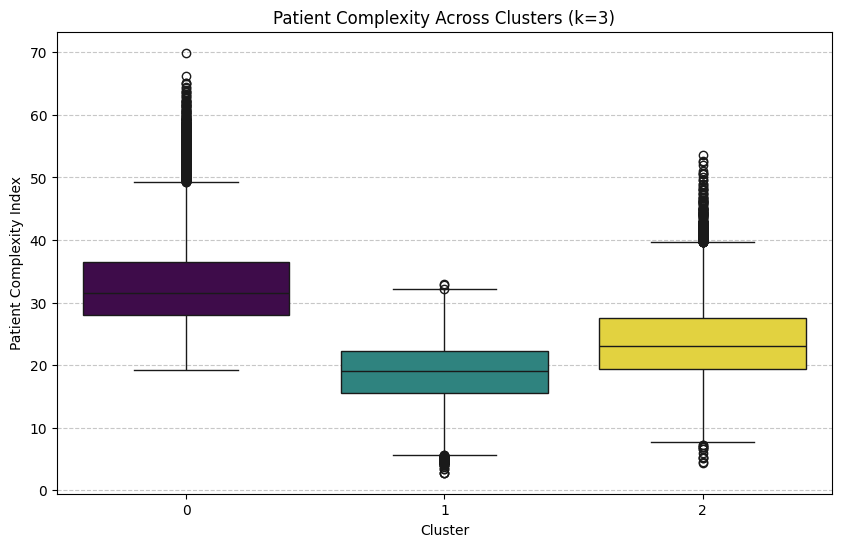

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the cluster_k4 column if it exists, as we are proceeding with k=3
if 'cluster_k4' in df.columns:
    df = df.drop(columns=['cluster_k4'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='patient_complexity', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Patient Complexity Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Patient Complexity Index')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

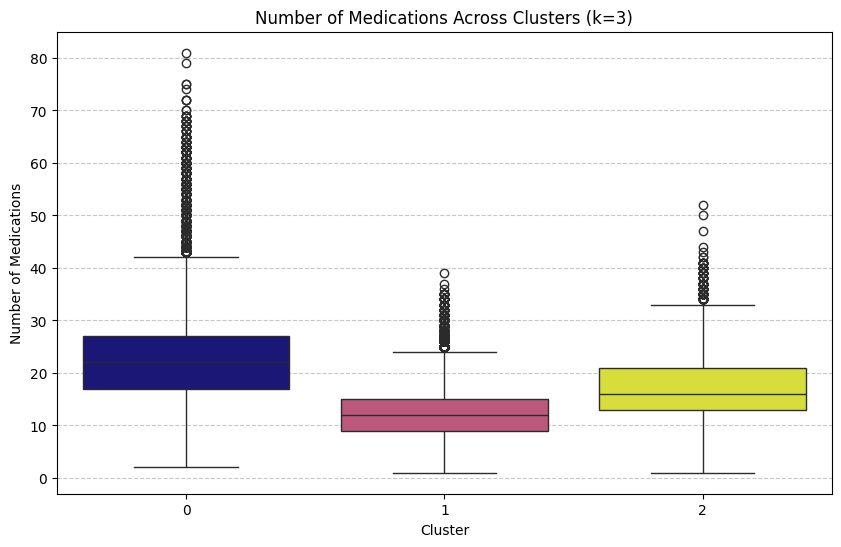

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num_medications', data=df, palette='plasma', hue='cluster', legend=False)
plt.title('Number of Medications Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Number of Medications')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

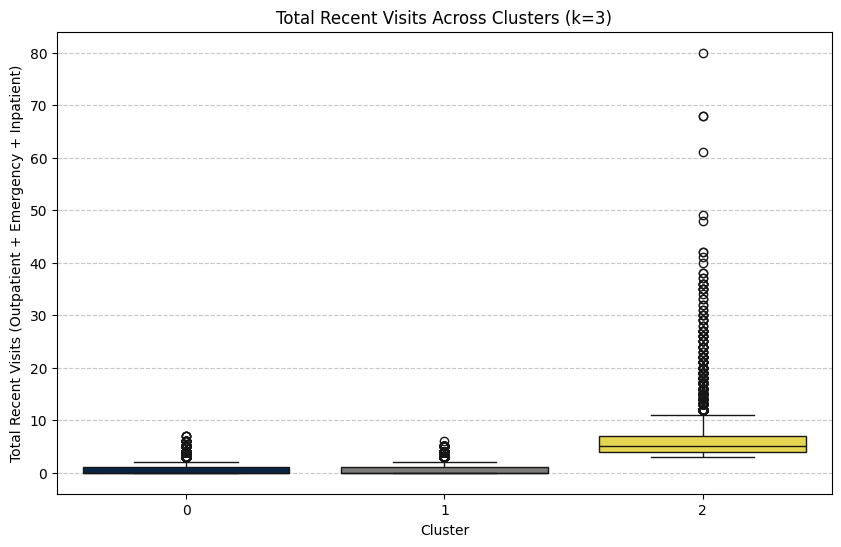

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='total_recent_visits', data=df, palette='cividis', hue='cluster', legend=False)
plt.title('Total Recent Visits Across Clusters (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Total Recent Visits (Outpatient + Emergency + Inpatient)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Re-evaluating with k=4

Let's re-run the clustering with `k=4` and analyze the clusters again.

### Interpreting Clusters for k=4 (Numerical Features)

Here's the summary of numerical features for each of the 4 clusters:

| cluster_k4 | number_inpatient | total_recent_visits | number_diagnoses | number_emergency | number_outpatient | time_in_hospital | patient_complexity | num_medications | insulin_user | medication_changed | num_procedures | has_renal_disease | num_lab_procedures |
|:-----------|:-----------------|:--------------------|:-----------------|:-----------------|:------------------|:-----------------|:-------------------|:----------------|:-------------|:-------------------|:---------------|:------------------|:-------------------|
| 0          | 0.35             | 0.65                | 7.00             | 0.08             | 0.22              | 3.32             | 19.44              | 12.40           | 0.00         | 0.17               | 1.06           | 0.05              | 38.52              |
| 1          | 3.50             | 7.24                | 8.10             | 1.43             | 2.31              | 4.51             | 24.06              | 17.33           | 0.62         | 0.51               | 0.93           | 0.16              | 44.60              |
| 2          | 0.50             | 0.83                | 8.37             | 0.11             | 0.22              | 7.96             | 35.99              | 25.24           | 0.69         | 0.62               | 2.91           | 0.12              | 55.11              |
| 3          | 0.42             | 0.75                | 7.16             | 0.12             | 0.22              | 3.36             | 20.59              | 14.03           | 1.00         | 0.67               | 0.77           | 0.08              | 40.39              |

### Interpreting Clusters for k=4 (Categorical Features)

**Engagement Pattern Distribution (k=4):**

| cluster_k4 | engagement_pattern_Acute_High_Risk | engagement_pattern_Low_Engagement | engagement_pattern_Mixed_Moderate | engagement_pattern_Preventive_Engaged |
|:-----------|:-----------------------------------|:----------------------------------|:----------------------------------|:--------------------------------------|
| 0          | 0.02                               | 0.98                              | 0.00                              | 0.00                                  |
| 1          | 0.74                               | 0.11                              | 0.11                              | 0.04                                  |
| 2          | 0.04                               | 0.96                              | 0.00                              | 0.00                                  |
| 3          | 0.03                               | 0.97                              | 0.00                              | 0.00                                  |

**Medical Specialty Distribution (k=4):**

| cluster_k4 | medical_specialty_? | medical_specialty_Cardiology | medical_specialty_Emergency/Trauma | medical_specialty_Family/GeneralPractice | medical_specialty_InternalMedicine | medical_specialty_Nephrology | medical_specialty_Orthopedics | medical_specialty_Orthopedics-Reconstructive | medical_specialty_Other | medical_specialty_Radiologist | medical_specialty_Surgery-General |
|:-----------|:--------------------|:-----------------------------|:-----------------------------------|:-----------------------------------------|:-----------------------------------|:-----------------------------|:------------------------------|:---------------------------------------------|:------------------------|:------------------------------|:----------------------------------|
| 0          | 0.48                | 0.06                         | 0.06                               | 0.08                                     | 0.13                               | 0.01                         | 0.02                          | 0.02                                         | 0.09                    | 0.01                          | 0.03                              |
| 1          | 0.57                | 0.03                         | 0.08                               | 0.07                                     | 0.12                               | 0.03                         | 0.00                          | 0.00                                         | 0.06                    | 0.01                          | 0.03                              |
| 2          | 0.50                | 0.06                         | 0.07                               | 0.06                                     | 0.13                               | 0.02                         | 0.01                          | 0.01                                         | 0.09                    | 0.01                          | 0.03                              |
| 3          | 0.48                | 0.04                         | 0.09                               | 0.08                                     | 0.17                               | 0.01                         | 0.01                          | 0.01                                         | 0.08                    | 0.01                          | 0.03                              |

### Validating Clusters for k=4 with Readmission Rates

Here are the readmission rates for each of the 4 clusters:

| cluster_k4 | readmission_rate_pct |
|:-----------|:---------------------|
| 0          | 40.89                |
| 1          | 74.53                |
| 2          | 47.17                |
| 3          | 45.05                |

### Comparison between k=3 and k=4

Let's compare the clusters identified with k=3 and k=4 based on the generated summaries and readmission rates.

**Key Observations for k=4:**

*   **Cluster 0 (k=4):** This cluster shows low numbers for inpatient, emergency, outpatient visits, and total recent visits. It has a very low insulin user rate (0%), lowest medication changed rate (17%), and a low readmission rate (40.89%). It primarily consists of patients with a 'Low_Engagement' pattern (98%). This cluster seems to capture patients with low complexity and low risk, similar to Cluster 1 from k=3 but with an even lower readmission rate.

*   **Cluster 1 (k=4):** This cluster has the highest inpatient, emergency, and total recent visits, alongside a high readmission rate (74.53%). It also has the highest 'Acute_High_Risk' engagement pattern (74%). This cluster strongly represents the high-risk, frequently hospitalized patient group, very similar to Cluster 2 from k=3, but with an even more pronounced readmission rate.

*   **Cluster 2 (k=4):** This cluster is characterized by the highest `time_in_hospital`, highest `patient_complexity`, highest `num_medications`, and highest `num_lab_procedures`. Its readmission rate is 47.17%. While it has a high `time_in_hospital`, its `number_inpatient`, `emergency`, and `outpatient` visits are relatively low, and 96% have 'Low_Engagement'. This suggests patients with high intrinsic complexity requiring longer hospital stays and more medical management, but not necessarily frequent readmissions. This cluster appears distinct from the k=3 clusters by separating high complexity/long stay from high readmission risk.

*   **Cluster 3 (k=4):** This cluster has 100% insulin users, high medication change (67%), and a readmission rate of 45.05%. The overall visit numbers and complexity are moderate. The engagement pattern is predominantly 'Low_Engagement' (97%). This cluster seems to identify a group of diabetes patients who are actively managed (insulin, medication changes) but might not be frequently visiting the hospital, or their frequent visits are not captured by the current features, making them a moderately complex group with moderate readmission risk.

**Conclusion on k=3 vs k=4:**

Both `k=3` and `k=4` provide meaningful clusters. However, `k=4` seems to offer a slightly more granular and potentially more actionable segmentation:

*   **Clearer High-Risk Group:** Cluster 1 in `k=4` is a very well-defined high-risk group with the highest readmission rate (74.53%), even higher than the high-risk cluster in `k=3` (72.61%).
*   **Distinction of High Complexity vs. High Readmission:** `k=4` introduces Cluster 2, which captures patients with high complexity and longer hospital stays but not necessarily the highest readmission rates, separating them from the 'Acute_High_Risk' group (Cluster 1, k=4). This distinction could be valuable for targeted interventions. For example, Cluster 2 might benefit from case management during their long stays to reduce complications, while Cluster 1 needs aggressive post-discharge support to prevent readmission.
*   **Identified Insulin-Dependent Group:** Cluster 3 in `k=4` specifically highlights insulin users with significant medication changes, which could be a specific target for diabetes management programs.

Given the slightly better differentiation in readmission rates and the more nuanced patient profiles, **k=4 appears to be a slightly better choice** for this dataset, offering more distinct and potentially actionable insights for patient management strategies.

In [32]:
optimal_k = 4
kmeans_model_k4 = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model_k4.fit(X_processed)

df['cluster_k4'] = kmeans_model_k4.labels_
display(df.head())

,race,gender,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,has_heart_disease,comorbidity_count,admission_type,is_emergency,patient_complexity,engagement_pattern,total_recent_visits,cluster,is_readmitted,cluster_k4
0,Caucasian,Female,1,Other,41,0,1,0,0,0,...,0,0,Unknown,0,2.814682,Low_Engagement,0,1,0,0
1,Caucasian,Female,3,?,59,0,18,0,0,0,...,0,0,Unknown,0,21.187151,Low_Engagement,0,1,1,3
2,AfricanAmerican,Female,2,?,11,5,13,2,0,1,...,0,0,Unknown,0,25.514302,Low_Engagement,3,1,0,0
3,Caucasian,Male,2,?,44,1,16,0,0,0,...,0,1,Unknown,0,19.033978,Low_Engagement,0,1,0,3
4,Caucasian,Male,1,?,51,0,8,0,0,0,...,0,0,Unknown,0,11.876933,Low_Engagement,0,1,0,3


### Interpreting Clusters for k=4 (Numerical Features)

Now, let's look at the mean of numerical features for the 4 clusters.

In [33]:
numeric_cols_selected = X_selected.select_dtypes(include=[np.number]).columns
cluster_summary_numeric_k4 = df.groupby('cluster_k4')[numeric_cols_selected].mean()
display(cluster_summary_numeric_k4)

,number_inpatient,total_recent_visits,number_diagnoses,number_emergency,number_outpatient,time_in_hospital,patient_complexity,num_medications,insulin_user,medication_changed,num_procedures,has_renal_disease,num_lab_procedures
cluster_k4,,,,,,,,,,,,,
0,0.354383,0.654533,7.000317,0.083749,0.216402,3.315027,19.435129,12.400121,0.000000,0.169080,1.057556,0.046978,38.522276
1,3.498105,7.242285,8.104900,1.430834,2.313346,4.514077,24.063047,17.334191,0.620736,0.513265,0.926773,0.155929,44.595019
2,0.500514,0.829753,8.370938,0.108704,0.220536,7.958349,35.990092,25.236272,0.688831,0.620471,2.912402,0.121264,55.106976
3,0.418847,0.750621,7.156115,0.115803,0.215971,3.363670,20.588502,14.032496,0.999829,0.671051,0.771076,0.075718,40.387264


### Interpreting Clusters for k=4 (Categorical Features)

Next, let's examine the distribution of categorical features across the 4 clusters.

In [34]:
categorical_cols_selected = X_selected.select_dtypes(include=['category']).columns

for col in categorical_cols_selected:
    print(f"\nDistribution of '{col}' across clusters (k=4):")
    display(pd.crosstab(df['cluster_k4'], df[col], normalize='index'))


Distribution of 'engagement_pattern' across clusters (k=4):


engagement_pattern,Acute_High_Risk,Low_Engagement,Mixed_Moderate,Preventive_Engaged
cluster_k4,,,,
0,0.020205,0.979267,0.000528,0.000000
1,0.737412,0.112886,0.109096,0.040606
2,0.040437,0.958115,0.001074,0.000374
3,0.025135,0.974837,0.000029,0.000000



Distribution of 'medical_specialty' across clusters (k=4):


medical_specialty,?,Cardiology,Emergency/Trauma,Family/GeneralPractice,InternalMedicine,Nephrology,Orthopedics,Orthopedics-Reconstructive,Other,Radiologist,Surgery-General
cluster_k4,,,,,,,,,,,
0,0.480494,0.064968,0.061803,0.078025,0.134288,0.011949,0.018438,0.017383,0.087494,0.011791,0.033368
1,0.567407,0.025582,0.081348,0.072279,0.121955,0.031132,0.003113,0.004061,0.056849,0.006632,0.029643
2,0.499300,0.061963,0.071255,0.058554,0.133218,0.020639,0.013308,0.010039,0.085684,0.014662,0.031378
3,0.480671,0.039171,0.088300,0.076859,0.165188,0.013923,0.011212,0.009386,0.078971,0.009415,0.026904


### Validating Clusters for k=4 with Readmission Rates

Finally, let's calculate the readmission rate for each of the 4 clusters to validate their distinctiveness.

In [35]:
readmission_rates_k4 = df.groupby('cluster_k4')['is_readmitted'].mean().reset_index()
readmission_rates_k4['readmission_rate_pct'] = (readmission_rates_k4['is_readmitted'] * 100).round(2)

display(readmission_rates_k4[['cluster_k4', 'readmission_rate_pct']])

,cluster_k4,readmission_rate_pct
0,0,40.89
1,1,74.53
2,2,47.17
3,3,45.05
